In [29]:

import tensorflow as tf
from tensorflow.keras.models import Sequential # Builds the layers one by one
from tensorflow.keras.layers import Dense #creates a fully connected layer

In [30]:
# Create a simple feed forward neural network
model = Sequential() #initialize the model
model.add(Dense(4, activation='relu', input_shape=(2,))) #input layer
model.add(Dense(3, activation='relu')) #hidden layer
model.add(Dense(1, activation='sigmoid')) #output layer

In [31]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Import libraries
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np


# Sample data # Training texts (movie reviews)
texts = [
    # --- Existing Data ---
    "guten morning is good morning",           # 1 positive
    "watches are good for your fitlook",        # 1 positive
    "pasta is tastly but unhealthy",            # 2 neutral
    "Dance is hard",                            # 0 negative
    "SRH is Best uni",                          # 1 positive
    "german language is hard",                  # 0 negative
    "german movies are good",                   # 1 positive
    "many german movie has no action parts",    # 0 negative
    "i dont like to dance",                     # 0 negative
    "germany is good but weather is bad",       # 2 neutral

    # --- New Positive (1) ---
    "i love german food",
    "SRH has great professors",
    "mannheim is a beautiful city",
    "i enjoy learning new languages",
    "the weather today is amazing",

    # --- New Negative (0) ---
    "this movie was really boring",
    "i hate waking up early",
    "the food was cold and tasteless",
    "german winters are too dark",
    "i dislike crowded places",

    # --- New Neutral (2) ---
    "germany has many universities",
    "pasta is made from wheat",
    "dance is a form of exercise",
    "the movie was two hours long",
    "mannheim is a city in germany",
]

labels = np.array([
    1, 1, 0.5, 0, 1, 0, 1, 0, 0, 0.5,
    1, 1, 1, 1, 1,
    0, 0, 0, 0, 0,
    0.5, 0.5, 0.5, 0.5, 0.5
])


# Create a Bag-of-Words vectorizer
vectorizer = TfidfVectorizer()

# Convert texts to numeric vectors
X = vectorizer.fit_transform(texts).toarray()

#Show all words learned from the dataset
print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nNumeric representation:")
print(X)


# Build FFNN
model = Sequential()
# Input layer + hidden layer
#  X.shape[1]: We set the input shape to the number of features (words) in our BoW representation
#8 = number of neurons in hidden layer
model.add(Dense(25,activation='relu',input_shape=(X.shape[1],)))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
model.summary()

# Train the model
history = model.fit(X, labels,
          epochs=100, #number of times the model will see the entire dataset
          verbose=0) #verbose=0 means no output during training


# Test the model with a new review
new_text = ["Indian's are bad in Hindi"]

# Convert the new text to a numeric vector using the same vectorizer
new_vector = vectorizer.transform(new_text).toarray()

# Make a prediction
prediction = model.predict(new_vector)

print("\nProbability:", prediction[0][0])
if prediction[0][0] > 0.65:
    print("Positive Review")
elif prediction[0][0] < 0.35:
    print("Negative Review")
else:
    print("Neutral Review")

Vocabulary:
['action' 'amazing' 'and' 'are' 'bad' 'beautiful' 'best' 'boring' 'but'
 'city' 'cold' 'crowded' 'dance' 'dark' 'dislike' 'dont' 'early' 'enjoy'
 'exercise' 'fitlook' 'food' 'for' 'form' 'from' 'german' 'germany' 'good'
 'great' 'guten' 'hard' 'has' 'hate' 'hours' 'in' 'is' 'language'
 'languages' 'learning' 'like' 'long' 'love' 'made' 'mannheim' 'many'
 'morning' 'movie' 'movies' 'new' 'no' 'of' 'parts' 'pasta' 'places'
 'professors' 'really' 'srh' 'tasteless' 'tastly' 'the' 'this' 'to'
 'today' 'too' 'two' 'unhealthy' 'uni' 'universities' 'up' 'waking' 'was'
 'watches' 'weather' 'wheat' 'winters' 'your']

Numeric representation:
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.43848919]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 25)             │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,926 (7.52 KB)

 Trainable params: 1,926 (7.52 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

Probability: 0.49399728
Neutral Review


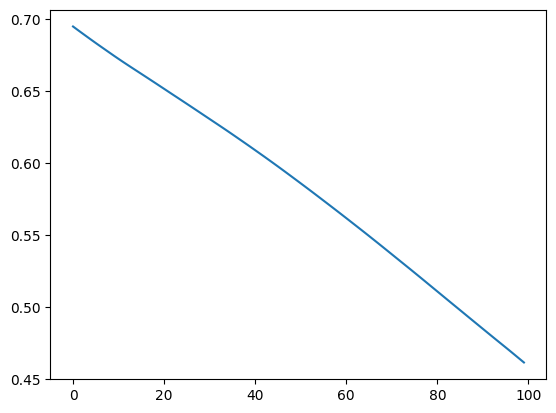

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


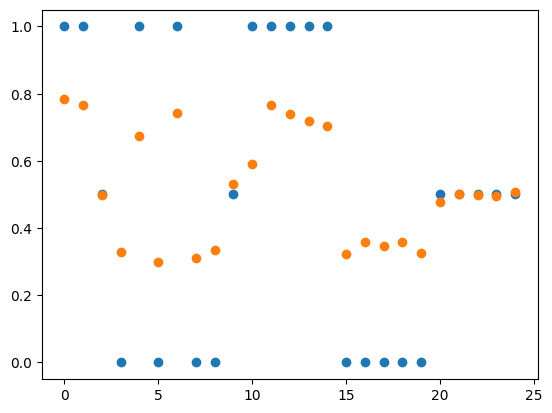

In [34]:
import matplotlib.pyplot as plt
# Training loss
plt.plot(history.history['loss'])
plt.show()

# Predictions
predictions = model.predict(X).flatten()

plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()